# <span style='background: linear-gradient(45deg, #6C63FF, #FF6B6B); -webkit-background-clip: text; -webkit-text-fill-color: transparent; font-family: "Inter", sans-serif; font-weight: 800; font-size: 1.8em;'>A/B-тестирование: анализ влияния рекламных кампаний на конверсию</span>

### Датасет: https://www.kaggle.com/datasets/amirmotefaker/ab-testing-dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
from scipy.stats import mannwhitneyu, shapiro, chi2_contingency
from statsmodels.stats.proportion import proportions_ztest

## 1. Загрузим данные и проведём очистку от пропусков

In [2]:
ctrl = pd.read_csv('../data/control_group.csv', sep=';')

In [3]:
test = pd.read_csv('../data/test_group.csv', sep=';')

### Посмотрим на датасет

In [4]:
ctrl.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [5]:
ctrl.shape

(30, 10)

In [6]:
test.head()

,Campaign Name,Date,Spend [USD],# of Impressions,Reach,# of Website Clicks,# of Searches,# of View Content,# of Add to Cart,# of Purchase
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


In [7]:
test.shape

(30, 10)

### Переименуем столбцы для удобства

In [8]:
rename = {
    'Campaign Name': 'campaign',
    'Date': 'date',
    'Spend [USD]': 'spend',
    '# of Impressions': 'impressions',
    'Reach': 'reach',
    '# of Website Clicks': 'clicks',
    '# of Searches': 'searches',
    '# of View Content': 'view_content',
    '# of Add to Cart': 'add_to_cart',
    '# of Purchase': 'purchases',
}

ctrl.rename(columns=rename, inplace=True)
test.rename(columns=rename, inplace=True)

In [9]:
ctrl.head()

,campaign,date,spend,impressions,reach,clicks,searches,view_content,add_to_cart,purchases
0,Control Campaign,1.08.2019,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0
1,Control Campaign,2.08.2019,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0
2,Control Campaign,3.08.2019,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0
3,Control Campaign,4.08.2019,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0
4,Control Campaign,5.08.2019,1835,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
test.head()

,campaign,date,spend,impressions,reach,clicks,searches,view_content,add_to_cart,purchases
0,Test Campaign,1.08.2019,3008,39550,35820,3038,1946,1069,894,255
1,Test Campaign,2.08.2019,2542,100719,91236,4657,2359,1548,879,677
2,Test Campaign,3.08.2019,2365,70263,45198,7885,2572,2367,1268,578
3,Test Campaign,4.08.2019,2710,78451,25937,4216,2216,1437,566,340
4,Test Campaign,5.08.2019,2297,114295,95138,5863,2106,858,956,768


### Добавим колонки 'group' со значением группы в датафреймы

In [11]:
ctrl['group'] = 'control'
test['group'] = 'test'

### Посмотрим на пропуски

In [12]:
print(f'\nВ CONTROL {len(ctrl)} строк до очистки')
print(f'\nВ TEST {len(ctrl)} строк до очистки')
print(f'\nПропуски в ctrl:\n{ctrl.isnull().sum()[ctrl.isnull().sum() > 0]}')
print(f'\nПропуски в test:\n{test.isnull().sum()[test.isnull().sum() > 0]}')


В CONTROL 30 строк до очистки

В TEST 30 строк до очистки

Пропуски в ctrl:
impressions     1
reach           1
clicks          1
searches        1
view_content    1
add_to_cart     1
purchases       1
dtype: int64

Пропуски в test:
Series([], dtype: int64)


### В ctrl имеются пропуски в столбцах, в test нет

## Удалим строки с пропусками

In [13]:
ctrl.dropna(inplace=True)
test.dropna(inplace=True)

### Переведём даты из текстового формата в формат дат

In [14]:
ctrl['date'] = pd.to_datetime(ctrl['date'], format='%d.%m.%Y')
test['date'] = pd.to_datetime(test['date'], format='%d.%m.%Y')

### Объединим датафреймы ctrl и test для удобства

In [15]:
df = pd.concat([ctrl, test], ignore_index=True)

In [16]:
df.head(round(len(df)/2))

,campaign,date,spend,impressions,reach,clicks,searches,view_content,add_to_cart,purchases,group
0,Control Campaign,2019-08-01,2280,82702.0,56930.0,7016.0,2290.0,2159.0,1819.0,618.0,control
1,Control Campaign,2019-08-02,1757,121040.0,102513.0,8110.0,2033.0,1841.0,1219.0,511.0,control
2,Control Campaign,2019-08-03,2343,131711.0,110862.0,6508.0,1737.0,1549.0,1134.0,372.0,control
3,Control Campaign,2019-08-04,1940,72878.0,61235.0,3065.0,1042.0,982.0,1183.0,340.0,control
4,Control Campaign,2019-08-06,3083,109076.0,87998.0,4028.0,1709.0,1249.0,784.0,764.0,control
5,Control Campaign,2019-08-07,2544,142123.0,127852.0,2640.0,1388.0,1106.0,1166.0,499.0,control
6,Control Campaign,2019-08-08,1900,90939.0,65217.0,7260.0,3047.0,2746.0,930.0,462.0,control
7,Control Campaign,2019-08-09,2813,121332.0,94896.0,6198.0,2487.0,2179.0,645.0,501.0,control
8,Control Campaign,2019-08-10,2149,117624.0,91257.0,2277.0,2475.0,1984.0,1629.0,734.0,control
9,Control Campaign,2019-08-11,2490,115247.0,95843.0,8137.0,2941.0,2486.0,1887.0,475.0,control


### Посмотрим на размеры датафреймов после очистки

In [17]:
ctrl.shape

(29, 11)

In [18]:
test.shape

(30, 11)

### Период и длительность проведения A/B теста

In [19]:
print('\nПериод:', df['date'].min().strftime('%d.%m.%Y'), '-', df['date'].max().strftime('%d.%m.%Y'))


Период: 01.08.2019 - 30.08.2019


In [20]:
time_of_test = df['date'].max() - df['date'].min()
print(time_of_test)

29 days 00:00:00


## 2. EDA - разведочный анализ данных

### Метрики

In [21]:
metrics = ['spend', 'impressions', 'reach', 'clicks', 'searches', 'view_content', 'add_to_cart', 'purchases']

### Сводная статистика по метрикам

In [22]:
summary = df.groupby('group')[metrics].agg(['sum', 'mean', 'std', 'median'])
summary

spend                                  impressions                 \
           sum         mean         std  median         sum           mean   
group                                                                        
control  66818  2304.068966  363.534822  2319.0   3177233.0  109559.758621   
test     76892  2563.066667  348.687681  2584.0   2237544.0   74584.800000   

                                     reach                ... view_content  \
                  std    median        sum          mean  ...          std   
group                                                     ...                
control  21688.922908  113430.0  2576503.0  88844.931034  ...   777.545469   
test     32121.377422   68853.5  1604747.0  53491.566667  ...   597.654669   

                add_to_cart                                  purchases  \
         median         sum         mean         std  median       sum   
group                                                                    
control  1984.0     37700.0  1300.000000  407.457973  1339.0   15161.0   
test     1881.0     26446.0   881.533333  347.584248   974.0   15637.0   

                                        
               mean         std median  
group                                   
control  522.793103  185.028642  501.0  
test     521.233333  211.047745  500.0  

[2 rows x 32 columns]

In [23]:
summary.T.round(2)

group                   control        test
spend        sum       66818.00    76892.00
             mean       2304.07     2563.07
             std         363.53      348.69
             median     2319.00     2584.00
impressions  sum     3177233.00  2237544.00
             mean     109559.76    74584.80
             std       21688.92    32121.38
             median   113430.00    68853.50
reach        sum     2576503.00  1604747.00
             mean      88844.93    53491.57
             std       21832.35    28795.78
             median    91579.00    44219.50
clicks       sum      154303.00   180970.00
             mean       5320.79     6032.33
             std        1757.37     1708.57
             median     5224.00     6242.50
searches     sum       64418.00    72569.00
             mean       2221.31     2418.97
             std         866.09      388.74
             median     2390.00     2395.50
view_content sum       56370.00    55740.00
             mean       1943.79     1858.00
             std         777.55      597.65
             median     1984.00     1881.00
add_to_cart  sum       37700.00    26446.00
             mean       1300.00      881.53
             std         407.46      347.58
             median     1339.00      974.00
purchases    sum       15161.00    15637.00
             mean        522.79      521.23
             std         185.03      211.05
             median      501.00      500.00

### Посмотрим на динамику метрик по дням

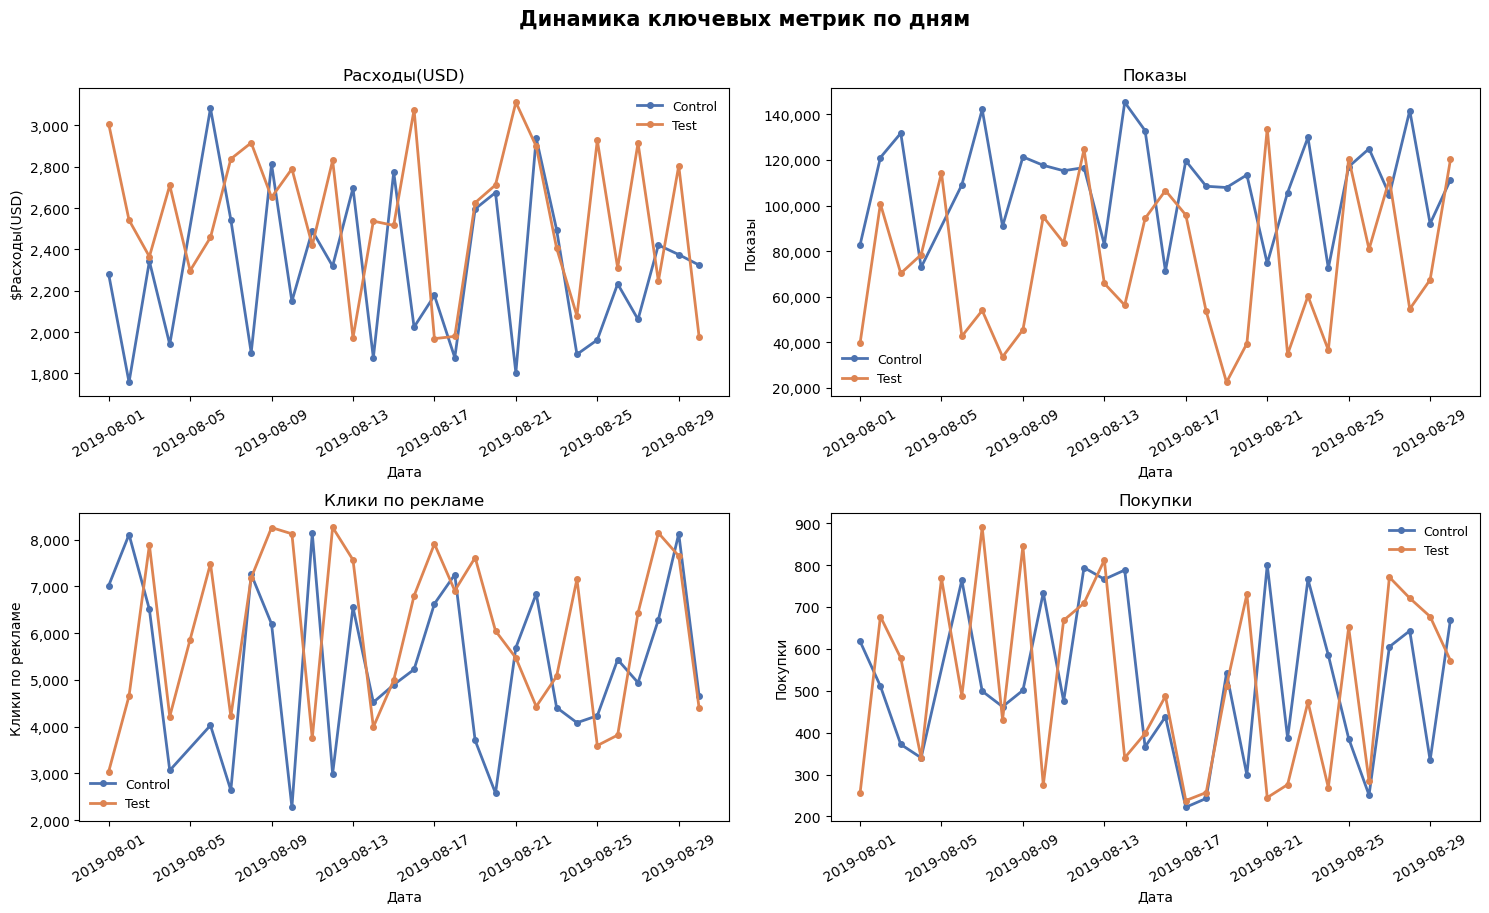

In [24]:
fig, axes = plt.subplots(2, 2, figsize=(15, 9))

fig.suptitle('Динамика ключевых метрик по дням', fontsize=15, fontweight='bold', y=1.01)

key_metrics = [
    ('spend', 'Расходы(USD)', '$'),
    ('impressions', 'Показы', ''),
    ('clicks', 'Клики по рекламе', ''),
    ('purchases', 'Покупки', '')
]

for ax, (col, label, prefix) in zip(axes.flatten(), key_metrics):
    ax.plot(ctrl['date'], ctrl[col], color='#4C72B0', lw=2, marker='o', ms=4, label='Control')
    ax.plot(test['date'], test[col], color='#DD8452', lw=2, marker='o', ms=4, label='Test')
    ax.set_title(label)
    ax.set_xlabel('Дата')
    ax.set_ylabel(f'{prefix}{label}')
    ax.legend(frameon=False, fontsize=9)
    ax.tick_params(axis='x', rotation=30)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()

## 3. Воронка конверсии

In [57]:
ctrl_sp = ctrl['spend'].sum()
test_sp = test['spend'].sum()

ctrl_sp

np.int64(66818)

In [58]:
test_sp

np.int64(76892)

In [32]:
funnel_cols = ['impressions', 'clicks', 'view_content', 'add_to_cart', 'purchases']
funnel_labels = ['Показы', 'Клики', 'Просмотр товара', 'Добавил в корзину', 'Покупка']

ctrl_f = ctrl[funnel_cols].sum()
test_f = test[funnel_cols].sum()

In [33]:
ctrl_f

impressions     3177233.0
clicks           154303.0
view_content      56370.0
add_to_cart       37700.0
purchases         15161.0
dtype: float64

In [51]:
test_f

impressions     2237544
clicks           180970
view_content      55740
add_to_cart       26446
purchases         15637
dtype: int64

### Таблица с абсолютными значениями и конверсией относительно показов

In [35]:
funnel_df = pd.DataFrame({
    'Шаг': funnel_labels,
    'Control (абс.)': ctrl_f.values.astype(int),
    'Test (абс.)': test_f.values.astype(int),
    'Control (% от показов)': (ctrl_f.values/ctrl_f['impressions']*100).round(3),
    'Test (% от показов)': (test_f.values/test_f['impressions']*100).round(3),
})

funnel_df

,Шаг,Control (абс.),Test (абс.),Control (% от показов),Test (% от показов)
0,Показы,3177233,2237544,100.000,100.000
1,Клики,154303,180970,4.857,8.088
2,Просмотр товара,56370,55740,1.774,2.491
3,Добавил в корзину,37700,26446,1.187,1.182
4,Покупка,15161,15637,0.477,0.699


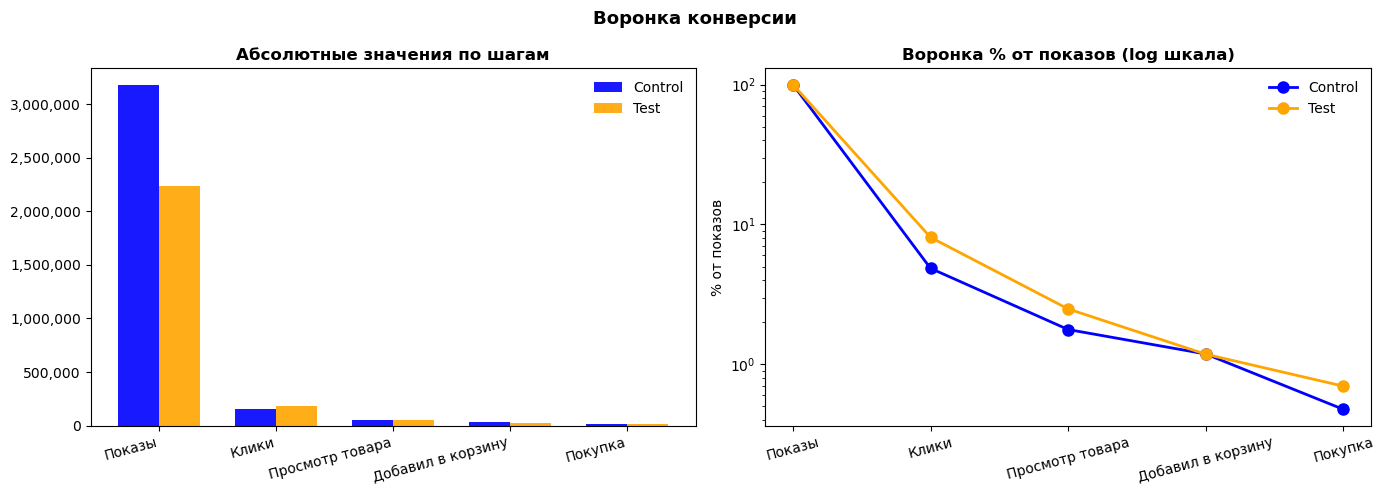

CTR: Control=4.857% | Test=8.088% | delta=+3.231%
CR: Control=9.825% | Test=8.641% | delta=-1.185%


In [44]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Абсолютные значения
x = np.arange(len(funnel_labels))
w=0.35
axes[0].bar(x-w/2, ctrl_f.values, w, label='Control', color='blue', alpha=0.9)
axes[0].bar(x+w/2, test_f.values, w, label='Test', color='orange', alpha=0.9)
axes[0].set_xticks(x)
axes[0].set_xticklabels(funnel_labels, rotation=15, ha='right')
axes[0].set_title('Абсолютные значения по шагам', fontweight='bold')
axes[0].legend(frameon=False)
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v):,}'))

#Нормализованная воронка (% от показов)
ctrl_norm = ctrl_f.values/ctrl_f['impressions']*100
test_norm = test_f.values/test_f['impressions']*100
axes[1].plot(funnel_labels, ctrl_norm, 'o-', color='blue', lw=2, ms=8, label='Control')
axes[1].plot(funnel_labels, test_norm, 'o-', color='orange', lw=2, ms=8, label='Test')
axes[1].set_yscale('log')
axes[1].set_title('Воронка % от показов (log шкала)', fontweight='bold')
axes[1].set_ylabel('% от показов')
axes[1].legend(frameon=False)
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Воронка конверсии', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

#CTR и итоговый CR
ctr_c = ctrl_f['clicks']/ctrl_f['impressions']
ctr_t = test_f['clicks']/test_f['impressions']
cr_c = ctrl_f['purchases']/ctrl_f['clicks']
cr_t = test_f['purchases']/test_f['clicks']

print(f'CTR: Control={ctr_c:.3%} | Test={ctr_t:.3%} | delta={ctr_t-ctr_c:+.3%}')
print(f'CR: Control={cr_c:.3%} | Test={cr_t:.3%} | delta={cr_t-cr_c:+.3%}')

## Вывод:
1. Тестовая кампания получает значительно более число кликов при меньшем числе показов (CTR: 4.9% vs 8.1%)
2. Проблема в том, что эти клики хуже конвертируются в покупку (CR: 9.8% vs 8.6%)
3. В конечном итоге получаем, что обе кампании приводят примерно одинаковое число покупок (примерно 15000 за период)

## 4. Статистические тесты

Для выбора теста проверяем нормальность распределений
Если оба распределения нормальны(p > 0.05) - t-тест Уэлча
Если хотя бы одно нет - тест Манна-Уитни
Для долей (CR, CTR) - z-тест на пропорциях

In [30]:
metrics_to_test = {
    'purchases': 'Покупки',
    'clicks': 'Клики',
    'add_to_cart': 'Добавления в корзину',
    'spend': 'Расходы (USD)',
}

print(f'{'Метрика':<25} {'p Shapiro C':>12} {'p Shapiro T':>12} {'Нормальность':>14}')
print('-' * 65)
for col, label in metrics_to_test.items():
    _, p_c = shapiro(ctrl[col])
    _, p_t = shapiro(test[col])
    normal = 'Да' if p_c > 0.05 and p_t > 0.05 else 'Нет -> MWU' 
    print(f'{label:<25} {p_c:>12.4f} {p_t:>12.4f} {normal:>14}')

Метрика                    p Shapiro C  p Shapiro T   Нормальность
-----------------------------------------------------------------
Покупки                         0.0896       0.0241     Нет -> MWU
Клики                           0.3043       0.0120     Нет -> MWU
Добавления в корзину            0.2525       0.0332     Нет -> MWU
Расходы (USD)                   0.3693       0.1171             Да


In [43]:
results = []
def test_metric(col, label, ctrl_data, test_data):
    mean_c, mean_t = ctrl_data.mean(), test_data.mean()
    _, p_c = shapiro(ctrl_data); _, p_t = shapiro(test_data)
    is_normal = p_c > 0.05 and p_t > 0.05

    if is_normal:
        _, p_val = stats.ttest_ind(ctrl_data, test_data, equal_var=False)
        test_name = 't-test'
    else:
        _, p_val = mannwhitneyu(ctrl_data, test_data, alternative='two-sided')
        test_name = 'Mann-Whitneyu U'

    results.append({
        'Метрика': label, 'Control': round(mean_c, 1), 'Test': round(mean_t, 1),
        'delta%': f'{(mean_t-mean_c)/mean_c*100:+.1f}%',
        'p-value': round(p_val, 4), 'Тест': test_name,
        'Вывод': 'Значимо' if p_val < 0.05 else 'Не значимо'
    })

for col, label in metrics_to_test.items():
    test_metric(col, label, ctrl[col], test[col])

# Z-тест для CTR
clicks_c, imp_c = int(ctrl['clicks'].sum()), int(ctrl['impressions'].sum())
clicks_t, imp_t = int(test['clicks'].sum()), int(test['impressions'].sum())
_, p_ctr = proportions_ztest([clicks_t, clicks_c], [imp_t, imp_c])
results.append({'Метрика': 'CTR (клики/показы)',
    'Control': f'{ctr_c:.3%}', 'Test': f'{ctr_t:.3%}',
    'delta%': f'{(ctr_t-ctr_c)/ctr_c*100:+.1f}%',
    'p-value': round(p_ctr, 6), 'Тест': 'z-тест (доли)',
    'Вывод': 'Значимо' if p_ctr < 0.05 else 'Не значимо'})

#Z-тест для CR
purch_c, purch_t = int(ctrl['purchases'].sum()), int(test['purchases'].sum())
_, p_cr = proportions_ztest([purch_t, purch_c], [clicks_t, clicks_c])
results.append({'Метрика': 'CTR (покупки/клики)',
    'Control': f'{cr_c:.3%}', 'Test': f'{cr_t:.3%}',
    'delta%': f'{(cr_t-cr_c)/cr_c*100:+.1f}%',
    'p-value': round(p_cr, 6), 'Тест': 'z-тест (доли)',
    'Вывод': 'Значимо' if p_ctr < 0.05 else 'Не значимо'
})

res_df = pd.DataFrame(results)
res_df

,Метрика,Control,Test,delta%,p-value,Тест,Вывод
0,Покупки,522.8,521.2,-0.3%,0.9577,Mann-Whitneyu U,Не значимо
1,Клики,5320.8,6032.3,+13.4%,0.1393,Mann-Whitneyu U,Не значимо
2,Добавления в корзину,1300.0,881.5,-32.2%,0.0005,Mann-Whitneyu U,Значимо
3,Расходы (USD),2304.1,2563.1,+11.2%,0.0071,t-test,Значимо
4,CTR (клики/показы),4.857%,8.088%,+66.5%,0.0000,z-тест (доли),Значимо
5,CTR (покупки/клики),9.825%,8.641%,-12.1%,0.0000,z-тест (доли),Значимо


## 5. Визуализация результатов

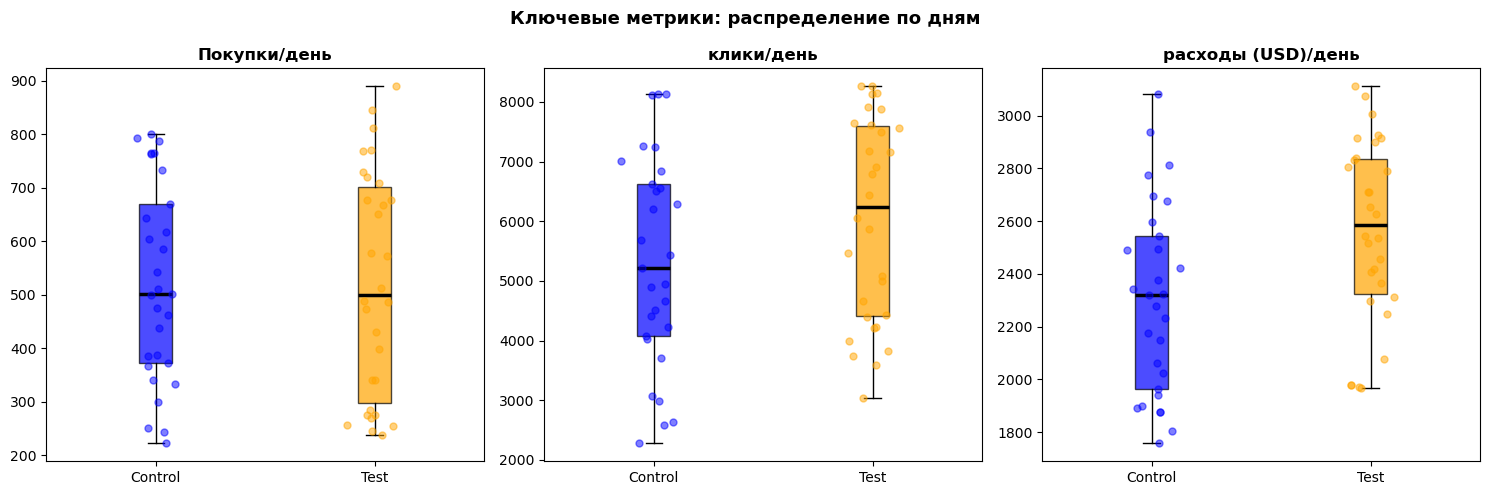

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Ключевые метрики: распределение по дням', fontsize=13, fontweight='bold')

box_metrics = [('purchases', 'Покупки/день'), ('clicks', 'клики/день'), ('spend', 'расходы (USD)/день')]

for ax, (col, label) in zip(axes, box_metrics):
    bp = ax.boxplot([ctrl[col].values, test[col].values],
                    tick_labels=['Control', 'Test'], patch_artist=True,
                    medianprops=dict(color='black', lw=2.5))
    bp['boxes'][0].set_facecolor('blue')
    bp['boxes'][0].set_alpha(0.7)
    bp['boxes'][1].set_facecolor('orange')
    bp['boxes'][1].set_alpha(0.7)

    #Показываем остальные дни
    for i, (data, color) in enumerate([(ctrl[col], 'blue'), (test[col], 'orange')], 1):
        ax.scatter(np.random.normal(i, 0.05, len(data)), data, alpha=0.5, color=color, s=25, zorder=3)
        ax.set_title(label, fontweight='bold')
plt.tight_layout()
plt.show()

### Доверительные интервалы для покупок (главная метрика)

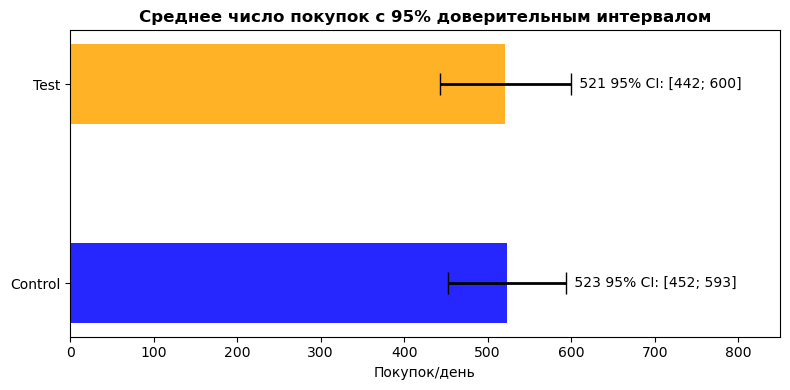

In [50]:
fig, ax = plt.subplots(figsize=(8, 4))

for i, (label, data, color) in enumerate([('Control', ctrl['purchases'], 'blue'), 
                                          ('Test', test['purchases'], 'orange')]):
    m = data.mean()
    ci = stats.t.interval(0.95, df=len(data)-1, loc=m, scale=data.sem())
    ax.barh(label, m, color=color, alpha=0.85, height=0.4)
    ax.errorbar(m, label, xerr=[[m-ci[0]], [ci[1]-m]],
               fmt='none', color='black', capsize=8, lw=2)
    ax.text(ci[1] + 5, i, f' {m:.0f} 95% CI: [{ci[0]:.0f}; {ci[1]:.0f}]',
            va='center', fontsize=10)

ax.set_xlabel('Покупок/день')
ax.set_title('Среднее число покупок с 95% доверительным интервалом', fontweight='bold')
ax.set_xlim(0, 850)
plt.tight_layout()
plt.show()

### Интервалы сильно перекрываются: нет оснований считать одну кампанию лучше другой по покупкам

### Затраты на контрольную и тестовую рекламную кампанию

In [62]:
ctrl_sp = ctrl['spend'].sum()
test_sp = test['spend'].sum()

int(ctrl_sp)

66818

In [63]:
int(test_sp)

76892

In [64]:
diff_sp = test_sp-ctrl_sp
int(diff_sp)

10074

## 6. Выводы и бизнес-рекомендации

## Основной инсайт 
Тестовая кампания привлекает аудиторию, которая охотнее кликает, но реже покупает. Это говорит о том, что расширенный таргетинг захватывает не интересующую нас ЦА. Более того, тестовая кампания оказалась дороже на 10074 USD

## Рекомендация
Продолжать использовать текущую кампанию:
Текущая аудитория лучше конвертируется на каждом шаге воронки, оставаясь при этом дешевле

## Что стоит исследовать дальше
1. Проверить, не зависит ли результат от дня недели (недельная сезонность)
2. Провести тест с user-level данными (здесь данные агрегированы по дням, что снижает статистическую мощность)